## Modules

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## SymNet

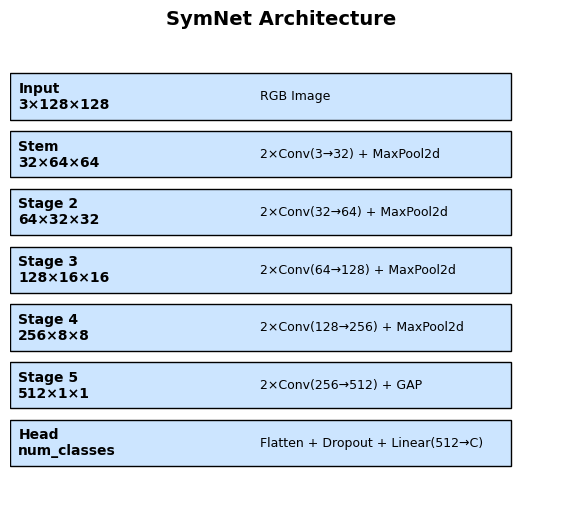

In [3]:
layers = [
    ("Input", "3×128×128", "RGB Image"),
    ("Stem", "32×64×64", "2×Conv(3→32) + MaxPool2d"),
    ("Stage 2", "64×32×32", "2×Conv(32→64) + MaxPool2d"),
    ("Stage 3", "128×16×16", "2×Conv(64→128) + MaxPool2d"),
    ("Stage 4", "256×8×8", "2×Conv(128→256) + MaxPool2d"),
    ("Stage 5", "512×1×1", "2×Conv(256→512) + GAP"),
    ("Head", "num_classes", "Flatten + Dropout + Linear(512→C)"),
]

fig, ax = plt.subplots(figsize=(7, 6))

for i, (name, shape, desc) in enumerate(layers):
    y = len(layers) - i - 1
    ax.add_patch(mpatches.Rectangle((0, y), 6, 0.8, edgecolor="black", facecolor="#cce5ff"))
    ax.text(0.1, y+0.4, f"{name}\n{shape}", va="center", ha="left", fontsize=10, fontweight="bold")
    ax.text(3.0, y+0.4, desc, va="center", ha="left", fontsize=9)

ax.set_xlim(0, 6.5)
ax.set_ylim(-0.5, len(layers)+0.5)
ax.axis("off")
plt.title("SymNet Architecture", fontsize=14, fontweight="bold")
plt.show()


## ProgNet

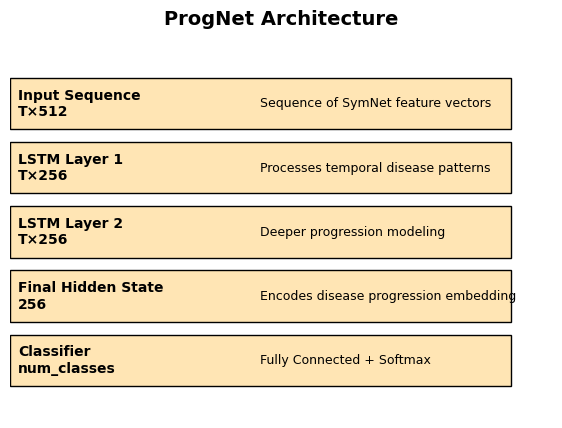

In [5]:
layers = [
    ("Input Sequence", "T×512", "Sequence of SymNet feature vectors"),
    ("LSTM Layer 1", "T×256", "Processes temporal disease patterns"),
    ("LSTM Layer 2", "T×256", "Deeper progression modeling"),
    ("Final Hidden State", "256", "Encodes disease progression embedding"),
    ("Classifier", "num_classes", "Fully Connected + Softmax"),
]

fig, ax = plt.subplots(figsize=(7, 5))

for i, (name, shape, desc) in enumerate(layers):
    y = len(layers) - i - 1
    ax.add_patch(mpatches.Rectangle((0, y), 6, 0.8, edgecolor="black", facecolor="#ffe5b4"))
    ax.text(0.1, y+0.4, f"{name}\n{shape}", va="center", ha="left", fontsize=10, fontweight="bold")
    ax.text(3.0, y+0.4, desc, va="center", ha="left", fontsize=9)

ax.set_xlim(0, 6.5)
ax.set_ylim(-0.5, len(layers)+0.5)
ax.axis("off")
plt.title("ProgNet Architecture", fontsize=14, fontweight="bold")
plt.show()

## CaneSight

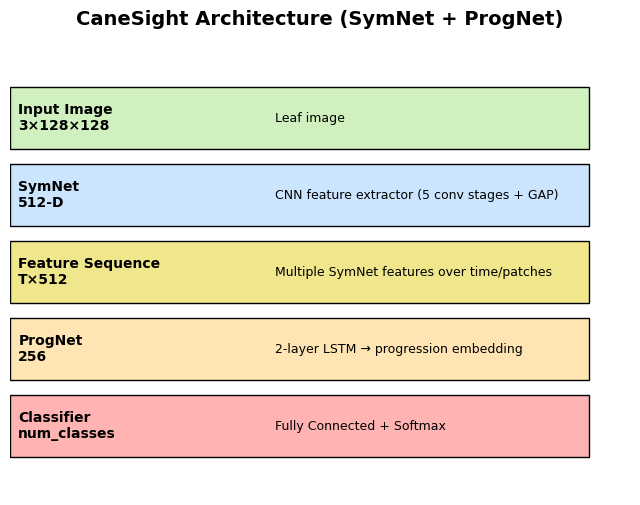

In [6]:
layers = [
    ("Input Image", "3×128×128", "Leaf image"),
    ("SymNet", "512-D", "CNN feature extractor (5 conv stages + GAP)"),
    ("Feature Sequence", "T×512", "Multiple SymNet features over time/patches"),
    ("ProgNet", "256", "2-layer LSTM → progression embedding"),
    ("Classifier", "num_classes", "Fully Connected + Softmax"),
]

fig, ax = plt.subplots(figsize=(8, 6))

for i, (name, shape, desc) in enumerate(layers):
    y = len(layers) - i - 1
    
    # different colors for CNN, LSTM, classifier
    if "SymNet" in name:
        color = "#cce5ff"  # blue
    elif "ProgNet" in name:
        color = "#ffe5b4"  # orange
    elif "Classifier" in name:
        color = "#ffb3b3"  # red
    elif "Feature" in name:
        color = "#f0e68c"  # yellow
    else:
        color = "#d0f0c0"  # green (input)
    
    ax.add_patch(mpatches.Rectangle((0, y), 7, 0.8, edgecolor="black", facecolor=color))
    ax.text(0.1, y+0.4, f"{name}\n{shape}", va="center", ha="left", fontsize=10, fontweight="bold")
    ax.text(3.2, y+0.4, desc, va="center", ha="left", fontsize=9)

ax.set_xlim(0, 7.5)
ax.set_ylim(-0.5, len(layers)+0.5)
ax.axis("off")
plt.title("CaneSight Architecture (SymNet + ProgNet)", fontsize=14, fontweight="bold")
plt.show()